<a href="https://colab.research.google.com/github/ahmed-zunaira/UTAT-Onboarding-Project/blob/main/UTAT_DL_Onboarding_Tuning_Hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 8.8 MB/s eta 0:00:00


In [ ]:
# importing libraries
import numpy as np
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.optim as optim
from sklearn.metrics import r2_score
from skorch import NeuralNetRegressor
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [ ]:
# loading the data
file_path = "/content/simpler_data_rwc.csv"
with open(file_path, 'r') as csvfile:
  data_reader = csv.reader(csvfile)

  data = []
  for row in data_reader:
    data.append(row)

data_np = np.array(data)
data_tensor = torch.from_numpy (data_np[1:,7:].astype(np.float32))
labels_tensor = torch.from_numpy (data_np[1:, 1:4].astype(np.float32))

dataset = TensorDataset(data_tensor, labels_tensor)
data_train, data_val, data_test = random_split(dataset, [0.7, 0.15, 0.15])

# combining data for grid search
all_indices = data_train.indices + data_val.indices

data_train_val = data_tensor[all_indices]
labels_train_val = labels_tensor[all_indices]

data_train_val_np = data_train_val.numpy()
labels_train_val_np = labels_train_val.numpy()

In [ ]:
# defining MLP with hyperparameters (layer size, activation function, and normalization scheme)

class MLP (nn.Module):
  def __init__ (self, neurons1=128, neurons2=128, activation='relu', normalization='none'):
    super (MLP, self).__init__()
    self.activation_type = activation

    self.layer1 = nn.Linear(210, neurons1)
    self.layer2 = nn.Linear (neurons1, neurons2)
    self.layer3 = nn.Linear (neurons2, 3)

    self.normalize1 = self.get_norm(normalization, neurons1)
    self.normalize2 = self.get_norm(normalization, neurons2)

  def forward(self, specs):
    activation1 = self.layer1(specs)
    activation1 = self.normalize1(activation1)
    activation1 = self.get_activation(activation1)
    activation2 = self.layer2(activation1)
    activation2 = self.normalize2(activation2)
    activation2 = self.get_activation(activation2)
    activation3 = self.layer3(activation2)
    output = torch.softmax(activation3, dim=-1)
    return output

  def get_norm (self, normalization, neurons):
    if (normalization == 'layer_norm'):
      return nn.LayerNorm(neurons)
    else:
      return nn.Identity()

  def get_activation (self, layer):
    if (self.activation_type == 'relu'):
      return F.relu(layer)
    elif (self.activation_type == 'leaky_relu'):
      return F.leaky_relu(layer)
    elif (self.activation_type == 'tanh'):
      return F.tanh(layer)
    elif (self.activation_type == 'silu'):
      return F.silu(layer)

In [ ]:
# define model
model = NeuralNetRegressor(module=MLP, criterion=nn.MSELoss, optimizer=optim.AdamW, verbose=0)

# define search space
param_dist = {
    'module__neurons1': [32, 64, 128, 256],
    'module__neurons2': [16, 32, 64, 128],
    'module__activation': ['relu', 'leaky_relu', 'tanh', 'silu'],
    'module__normalization': ['layer_norm', 'none'],
    'batch_size' : [16, 32, 64],
    'lr' : [0.0001, 0.001, 0.01],
    'optimizer__weight_decay' : [1e-4, 1e-3, 1e-2]
}

# define search
search = RandomizedSearchCV (estimator=model, param_distributions=param_dist, n_iter=200,scoring='r2', cv=3, random_state=1)

start_time = time.time()

# execute search
result = search.fit(data_train_val_np, labels_train_val_np)

end_time = time.time()
total_time = end_time - start_time

# summarize result
print ("Best score:", result.best_score_)
print ("Best Hyperparameters: ", result.best_params_)
print ("Search took: {:.2f} seconds".format(total_time))

Best score: 0.7856062054634094
Best Hyperparameters:  {'optimizer__weight_decay': 0.001, 'module__normalization': 'layer_norm', 'module__neurons2': 128, 'module__neurons1': 256, 'module__activation': 'leaky_relu', 'lr': 0.0001, 'batch_size': 16}
Search took: 425.15 seconds


In [ ]:
def plot_loss(epochs):
  val_loss = np.loadtxt("model_MLP_epoch{}_val_loss.csv".format(epochs))
  train_loss = np.loadtxt("model_MLP_epoch{}_train_loss.csv".format(epochs))

  plt.title("Train & Validation Loss")

  plt.plot (range(1, epochs+1), train_loss, label="Train")
  plt.plot (range(1, epochs+1), val_loss, label="Validation")

  plt.xlabel ("Epoch")
  plt.ylabel("Loss")
  plt.legend(loc='best')
  plt.show()

def plot_r2 (data_type, epochs):
  r2_values = np.loadtxt("model_MLP_epoch{}_{}_r2.csv".format(epochs, data_type))

  plt.title ("Predicted vs. True Abundances: Validation (R-Squared)")

  plt.plot (range(1, epochs+1), r2_values)

  plt.xlabel ("Epoch")
  plt.ylabel("R-Squared Value")
  plt.show()

def plot_test ():
  true_values = np.loadtxt("model_MLP_test_output_true.csv")
  predicted_values = np.loadtxt("model_MLP_test_output_prediction.csv")

  plt.title ("Predicted vs. True Abundances: Testing")

  plt.scatter(true_values[:,0], predicted_values[:,0], color='green', label='GV')
  plt.scatter(true_values[:,1], predicted_values[:,1], color='red', label='NPV')
  plt.scatter(true_values[:,2], predicted_values[:,2], color='brown', label='Soil')

  min_val = np.min(true_values)
  max_val = np.max(true_values)
  plt.plot ([min_val, max_val], [min_val, max_val], linestyle='--')

  plt.legend(loc='best')

  plt.xlabel("True Abundance")
  plt.ylabel("Predicted Abundance")

  plt.show()

def test_MLP (net, data_test, batch_size):
  test_dataloader = DataLoader (data_test, batch_size=batch_size, shuffle=True)

  total_loss_test = 0.0
  model_outputs = []
  labels_test = []

  net.eval()

  criterion = nn.MSELoss()

  for i, (inputs, labels) in enumerate(test_dataloader):
    outputs = net(inputs)
    model_outputs.append(outputs.detach().numpy())
    labels_test.append(labels.detach().numpy())
    loss_test = criterion (outputs, labels.float())

    total_loss_test += loss_test.item()

  labels_test = np.vstack(labels_test)
  model_outputs = np.vstack(model_outputs)

  r2 = r2_score (labels_test, model_outputs)
  loss = total_loss_test / (i+1)

  np.savetxt ("model_MLP_test_output_true.csv", labels_test)
  np.savetxt ("model_MLP_test_output_prediction.csv", model_outputs)

  return r2, loss


# evaluating the model on validation data
def evaluate_MLP (net, val_dataloader, criterion):
  total_loss_val = 0.0
  model_outputs = []
  labels_val = []

  net.eval()

  for i, (inputs, labels) in enumerate(val_dataloader):
    outputs = net(inputs)
    model_outputs.append(outputs.detach().numpy())
    labels_val.append(labels.detach().numpy())
    loss_val = criterion (outputs, labels.float())

    total_loss_val += loss_val.item()

  r2 = r2_score (np.vstack(labels_val), np.vstack(model_outputs))
  loss = total_loss_val / (i+1)

  return r2, loss


# defining training function for model
def train_MLP (net, batch_size, data_train, data_val, lr, weight_decay, num_epochs=30):
  # setting up dataloaders
  train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True)
  val_dataloader = DataLoader (data_val, batch_size=batch_size, shuffle=True)

  # setting manual seed for replication
  torch.manual_seed(1)
  best_epoch = 0
  best_val_r2 = 0

  # setting loss function and optimizer
  criterion = nn.MSELoss()
  optimizer = optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)

  # setting up arrays to store losses over epochs
  train_loss = np.zeros(num_epochs)
  val_loss = np.zeros(num_epochs)
  val_r2 = np.zeros(num_epochs)

  start_time = time.time()

  for epoch in range(num_epochs):
    net.train()
    total_loss_train = 0.0

    for i, (inputs, labels) in enumerate(train_dataloader):

      optimizer.zero_grad()

      outputs = net(inputs)

      loss = criterion(outputs, labels.float())
      loss.backward()

      optimizer.step()

      total_loss_train += loss.item()

    train_loss[epoch] = float(total_loss_train) / (i+1)
    val_r2[epoch], val_loss[epoch] = evaluate_MLP (net, val_dataloader, criterion)

    if (val_r2[epoch] > best_val_r2):
      best_val_r2= val_r2[epoch]
      best_epoch = epoch+1

    print (("Epoch {}: Train loss: {}, Validation loss: {}, Validation r2: {}").format(epoch+1, train_loss[epoch], val_loss[epoch], val_r2[epoch]))
    torch.save(net.state_dict(), "model_MLP_epoch{}".format(epoch+1))

  print ("Training is complete.")
  end_time = time.time()
  total_time = end_time - start_time

  print ("Total time: {:.2f} seconds". format(total_time))

  # putting training & validation loss + loss r^2 values in files to plot after
  np.savetxt ("model_MLP_epoch{}_train_loss.csv".format(num_epochs), train_loss)
  np.savetxt ("model_MLP_epoch{}_val_loss.csv".format(num_epochs), val_loss)
  np.savetxt ("model_MLP_epoch{}_val_r2.csv".format(num_epochs), val_r2)

  return best_epoch

In [ ]:
mlp = MLP(result.best_params_['module__neurons1'], result.best_params_['module__neurons2'], result.best_params_['module__activation'], result.best_params_['module__normalization'])

epoch_val = train_MLP(mlp, result.best_params_['batch_size'], data_train, data_val, result.best_params_['lr'], result.best_params_['optimizer__weight_decay'], 100)

Epoch 1: Train loss: 0.054898597422595084, Validation loss: 0.04614826719112256, Validation r2: 0.5448122620582581
Epoch 2: Train loss: 0.037061993437083926, Validation loss: 0.02865911598372109, Validation r2: 0.6822659373283386
Epoch 3: Train loss: 0.028020983892738036, Validation loss: 0.026717134258326364, Validation r2: 0.7220333218574524
Epoch 4: Train loss: 0.02346397550335448, Validation loss: 0.02043977796154864, Validation r2: 0.7709434628486633
Epoch 5: Train loss: 0.02095277478771382, Validation loss: 0.018057539620820212, Validation r2: 0.7999210953712463
Epoch 6: Train loss: 0.017377832561339204, Validation loss: 0.017627656076322582, Validation r2: 0.8188669085502625
Epoch 7: Train loss: 0.01627414007548635, Validation loss: 0.014664097004296148, Validation r2: 0.8295019268989563
Epoch 8: Train loss: 0.015259894180895859, Validation loss: 0.01736205884748522, Validation r2: 0.7972521781921387
Epoch 9: Train loss: 0.014274566814205364, Validation loss: 0.01551675180192379

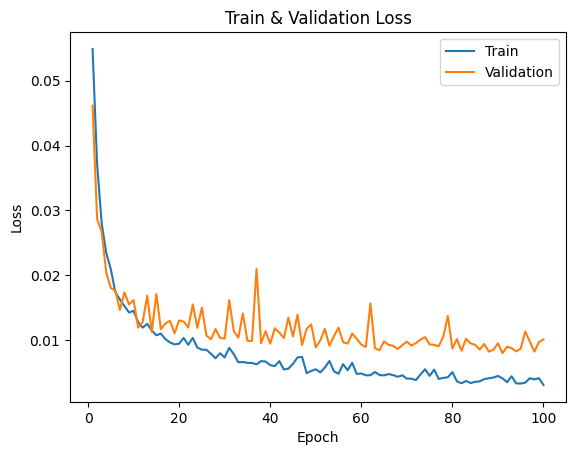

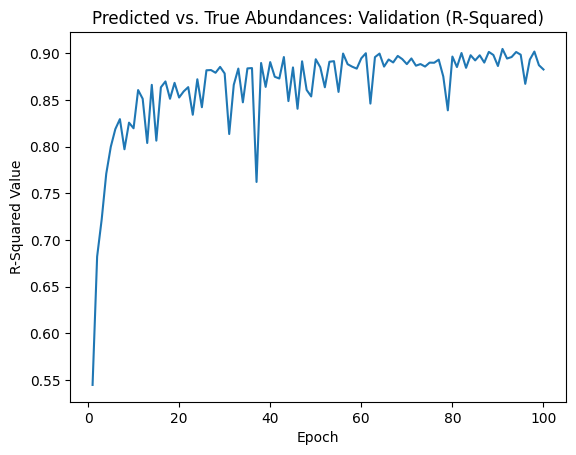

In [ ]:
plot_loss(100)
plot_r2('val', 100)

Epoch 1: Train loss: 0.05283407188069664, Validation loss: 0.0439636862343725, Validation r2: 0.5514537692070007
Epoch 2: Train loss: 0.037138355479232575, Validation loss: 0.028460567324038816, Validation r2: 0.6885817646980286
Epoch 3: Train loss: 0.02980811278776903, Validation loss: 0.026138388880473727, Validation r2: 0.7194342017173767
Epoch 4: Train loss: 0.025046151719595258, Validation loss: 0.02178865988903186, Validation r2: 0.7568669319152832
Epoch 5: Train loss: 0.020413326111769204, Validation loss: 0.019105132614426753, Validation r2: 0.7852983474731445
Epoch 6: Train loss: 0.017209354169225616, Validation loss: 0.017716034151175442, Validation r2: 0.8055060505867004
Epoch 7: Train loss: 0.01566160159602173, Validation loss: 0.015170911327004433, Validation r2: 0.82546067237854
Epoch 8: Train loss: 0.014394770302858791, Validation loss: 0.014859094864839469, Validation r2: 0.8226973414421082
Epoch 9: Train loss: 0.013860451768299467, Validation loss: 0.014717563274590409

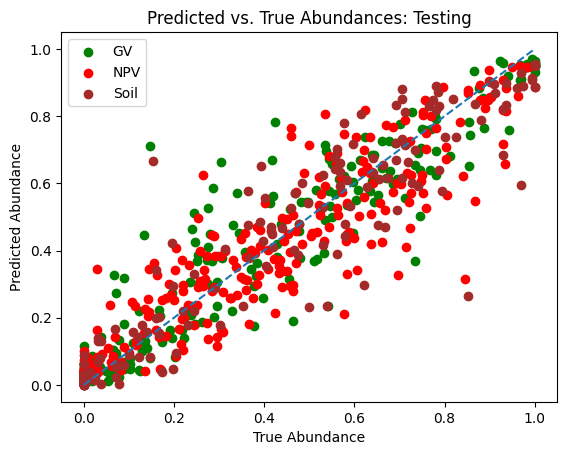

In [ ]:
mlp = MLP(result.best_params_['module__neurons1'], result.best_params_['module__neurons2'], result.best_params_['module__activation'], result.best_params_['module__normalization'])

train_MLP(mlp, result.best_params_['batch_size'], data_train, data_val, result.best_params_['lr'], result.best_params_['optimizer__weight_decay'], epoch_val)

test_r2, test_loss = test_MLP(mlp, data_test, result.best_params_['batch_size'])

print ("R-Squared value of testing data:", test_r2)
plot_test()